# Chapter 15: Моделирование последовательных данных с помощью рекуррентных неиронных сетей (Часть 1)


Предыдущая глава была посвящена сверточным нейронным сетям (CNN). Мы рассмотрели функциональные блоки этой архитектуры и способы реализации глубоких CNN в PyTorch. Вы также узнали, как использовать CNN для классификации изображений. Здесь же мы познакомимся с рекуррентными нейронными сетями (RNN) и их применением в моделировании последовательных данных.\
В этой главе будут рассмотрены следующие темы:\
♦ понятие последовательных данных;\
♦ RNN для моделирования последовательностей;\
♦ долгая краткосрочная память;\
♦ усеченное обратное распространение во времени;\
♦ реализация многослойной RNN для моделирования последовательности в PyTorch;\
♦ первый проект: анализ эмоциональной окраски в наборе данных обзоров фильмов IMDb;\
♦ второй проект: моделирование языка на уровне символов с ячейками LSTM на текстовых данных из книги Жюля Верна «Таинственный остров»;\
♦ использование обрезки градиента, чтобы избежать взрыва градиентов. 

In [1]:
from IPython.display import Image
%matplotlib inline 

# 15.1. Знакомство с понятием последовательных данных 



Давайте начнем обсуждение RNN с рассмотрения природы последовательных данных (sequential data), которые часто называют просто последовательностями (sequence). Мы рассмотрим уникальные свойства последовательностей, которые отличают их от других видов данных. Затем вы познакомитесь со способами представления последовательных данных и с различными категориями моделей для последовательных данных, которые основаны на входах и выходах модели. Это поможет нам исследовать связь между RNN и последовательностями. 

### 15.1.1. Моделирование последовательных данных: порядок имеет значение 

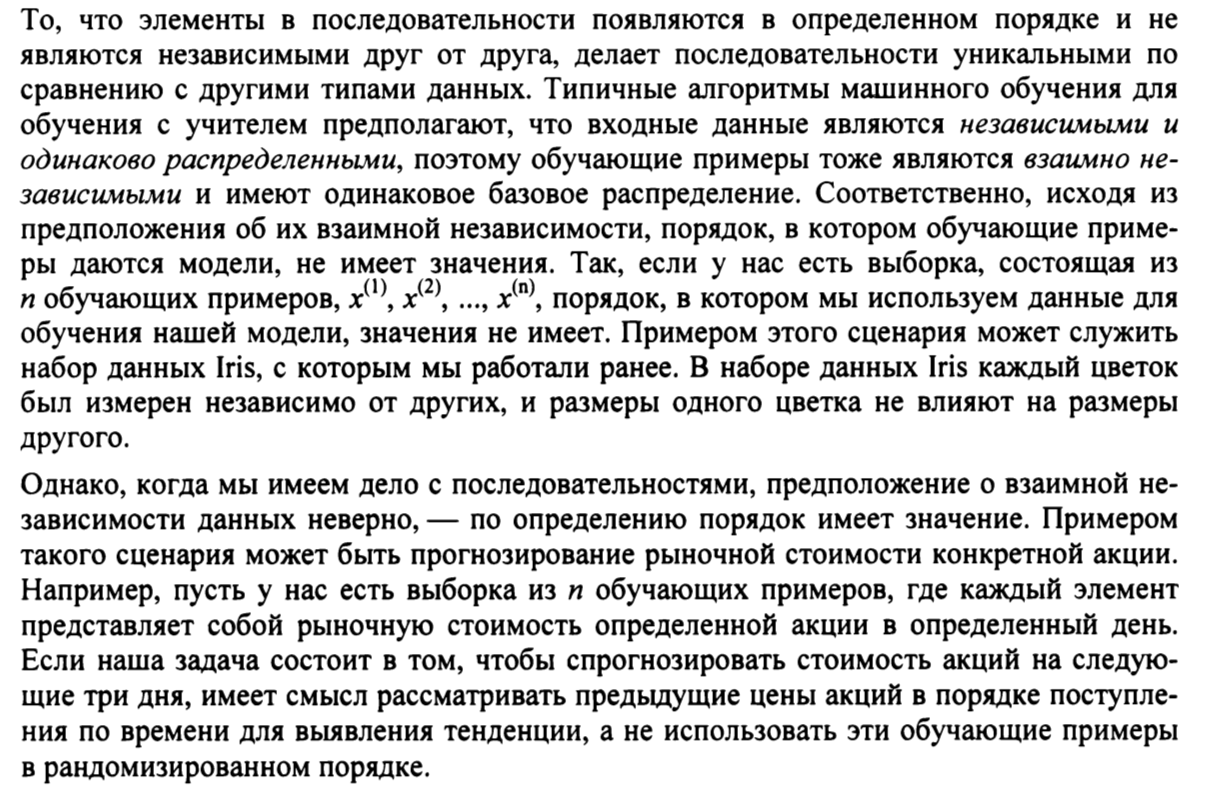

In [2]:
Image(filename='figures/текст1.png', width=700)

### 15.1.2. Данные временных рядов - особый тип последовательных данных 

Данные временных рядов - это особый тип последовательных данных, где каждый пример связан с измерением времени. В данных временных рядов выборки берутся с последовательными временными метками, и поэтому измерение времени определяет порядок точек данных. Например, данными временных рядов являются курсы акций и голосовые записи.

С другой стороны, не все последовательные данные имеют измерение времени. Например, в текстовых данных или последовательностях ДНК экземпляры упорядочены, но текст или ДНК не имеют составляющую времени. В этой главе мы сосредоточимся на примерах обработки естественного языка (Natural Language Processing, NLP) и моделирования текста, которые не являются данными временных рядов. Надо, впрочем, заметить, что RNN также можно использовать для данных временных рядов, но их рассмотрение выходит за рамки этой книги. 

### 15.1.3. Способы представления последовательностей 

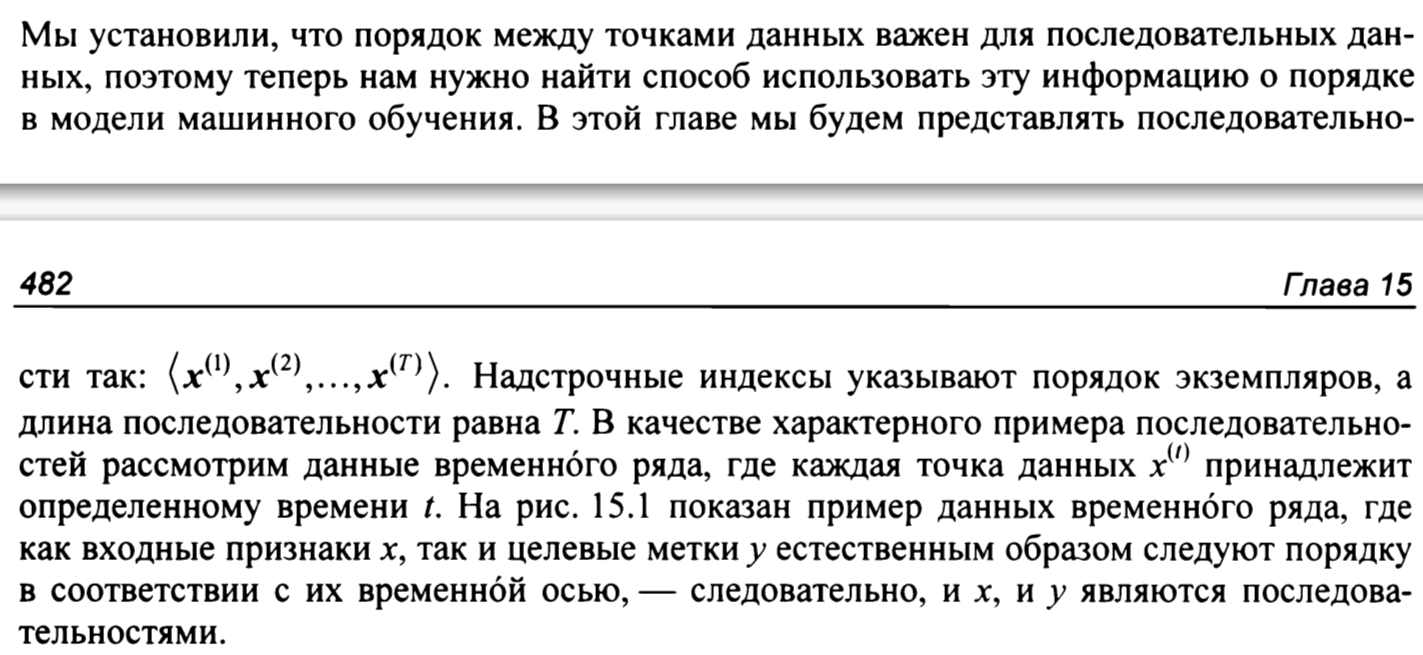

In [3]:
Image(filename='figures/текст2.png', width=700)

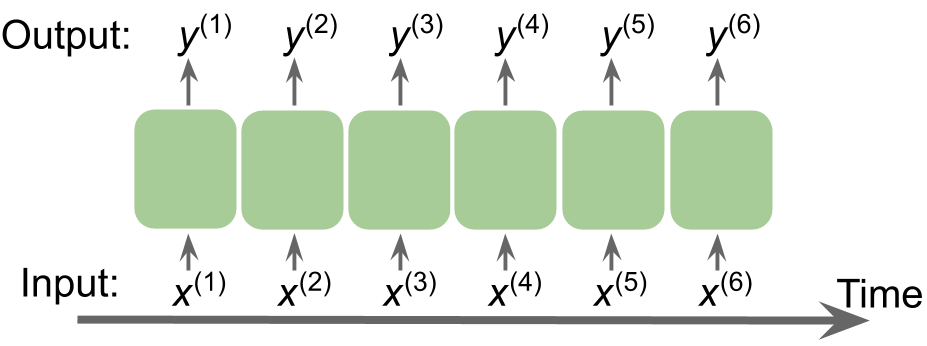

In [4]:
Image(filename='figures/15_01.png', width=500)

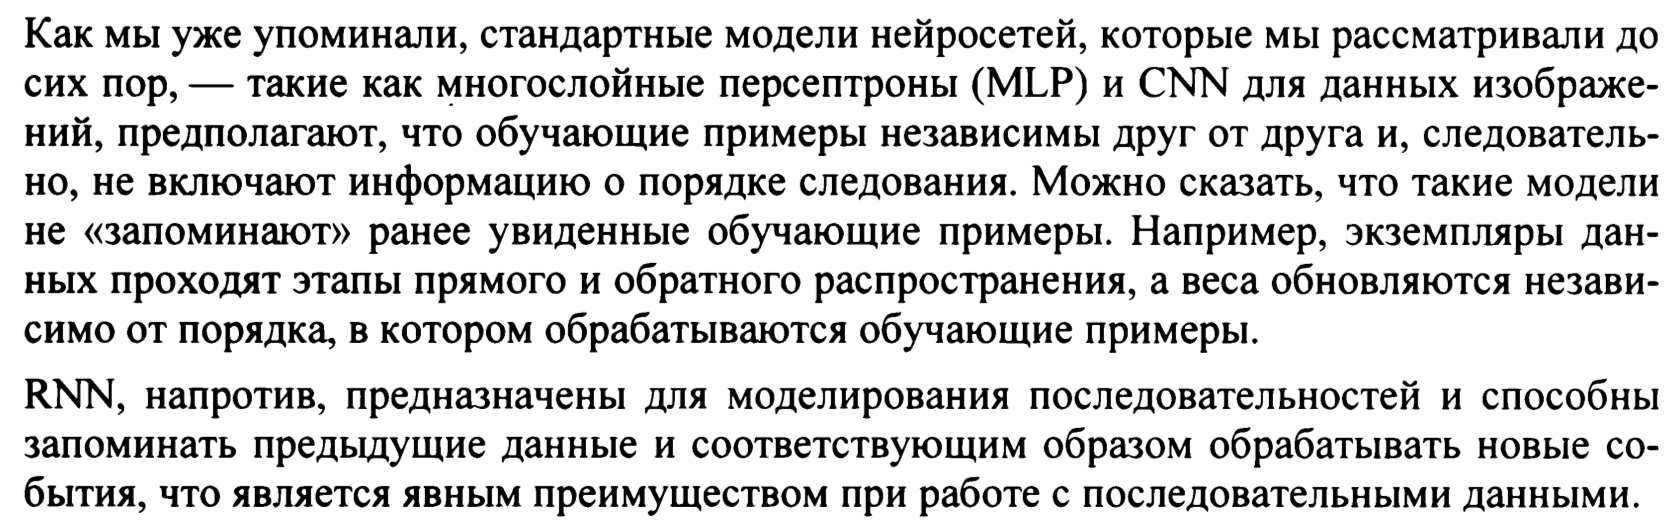

In [5]:
Image(filename='figures/текст3.png', width=700)

## 15.1.4. Различные категории моделирования последовательности 

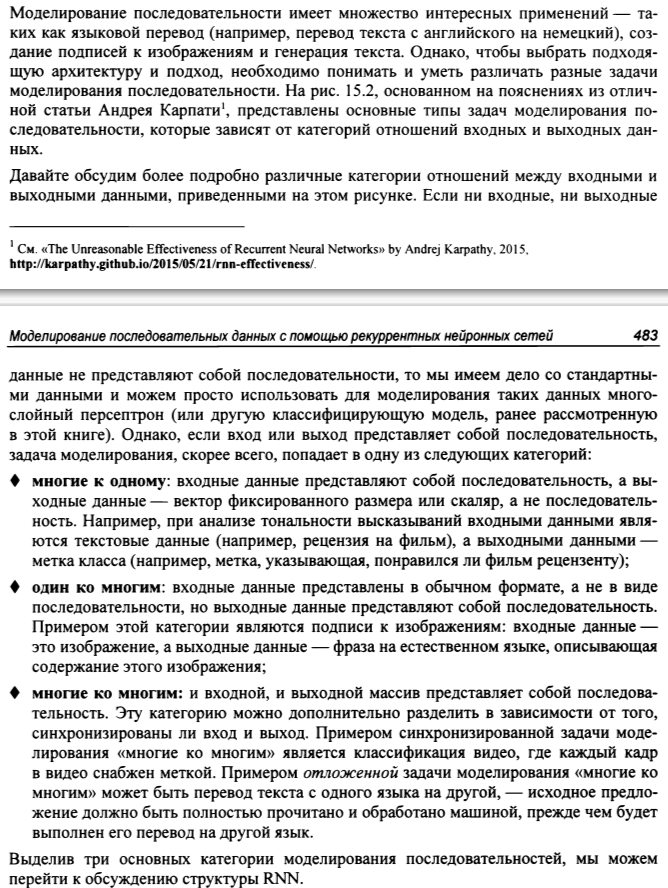

In [6]:
Image(filename='figures/текст4.png', width=700)

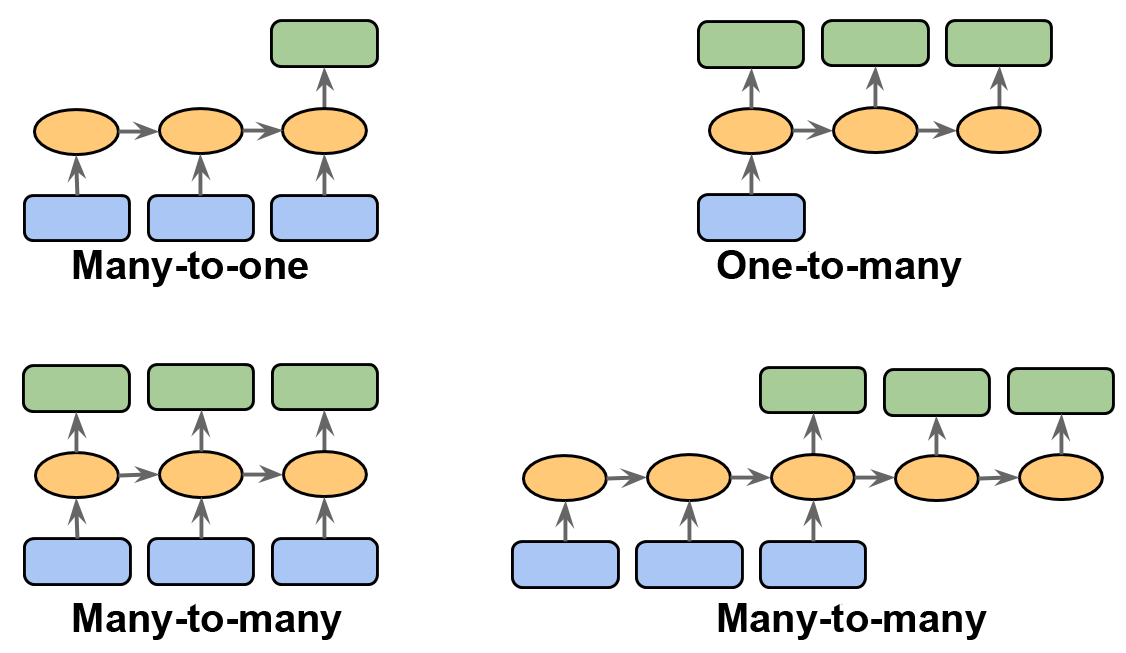

In [7]:
Image(filename='figures/15_02.png', width=500)

### 15.2. RNN  для моделирования последовательностей

В этом разделе, прежде чем приступить к реализации RNN  в  PyTorch,  мы обсудим основные принципы работы рекуррентной нейросети. Начнем мы с рассмотрения ти­пичной структуры RNN,  которая содержит рекурсивный компонент для моделирования последовательных данных. После чего узнаем, как в типичной RNN  вычисляется акти­вация нейронов. Эти знания послужат основой для понимания общих проблем при обу­чении RNN,  а затем мы обсудим решения этих проблем, такие как LSTM  (Long  Short-Term  Memory, сети долгой кратковременной памяти) и управляемые рекуррентные блоки (Gated Recurrent Units,  GRU). 

#### 15.2.1. Определение потока данных в RNN

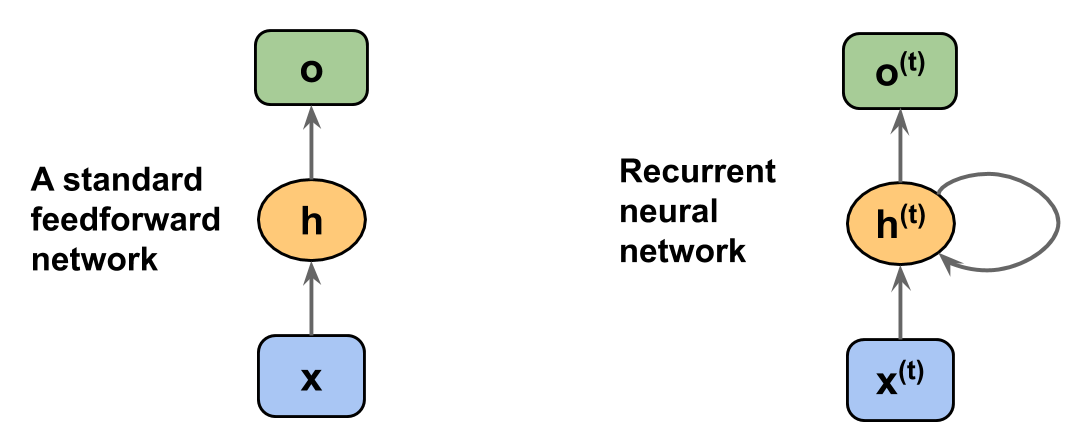

In [8]:
Image(filename='figures/15_03.png', width=500)

в RNN скрытый слой получает входные данные как от входного слоя текущего временного шага, так и от скрытого слоя предыдущего временного шага. 
Поток информации в смежных временнь1х шагах в скрытом слое позволяет сети пом­нить о прошлых событиях. Этот поток информации обычно отображается в виде петли, также известной - в терминах графовых структур - как рекуррентное ребро (recurrent edge), откуда и происходит название архитектуры RNN. 
Подобно многослойным персептронам, RNN  могут состоять из нескольких скрытых слоев. Имейте в виду, что RNN  с одним скрытым слоем принято называть однослойной RNN,  которую не следует путать с однослойными нейросетями без скрытого слоя, та­кими как Adaline  или логистическая регрессия. На рис. 15.4  показаны RNN  с одним скрытым слоем (вверху) и RNN  с двумя скрытыми слоями (внизу).

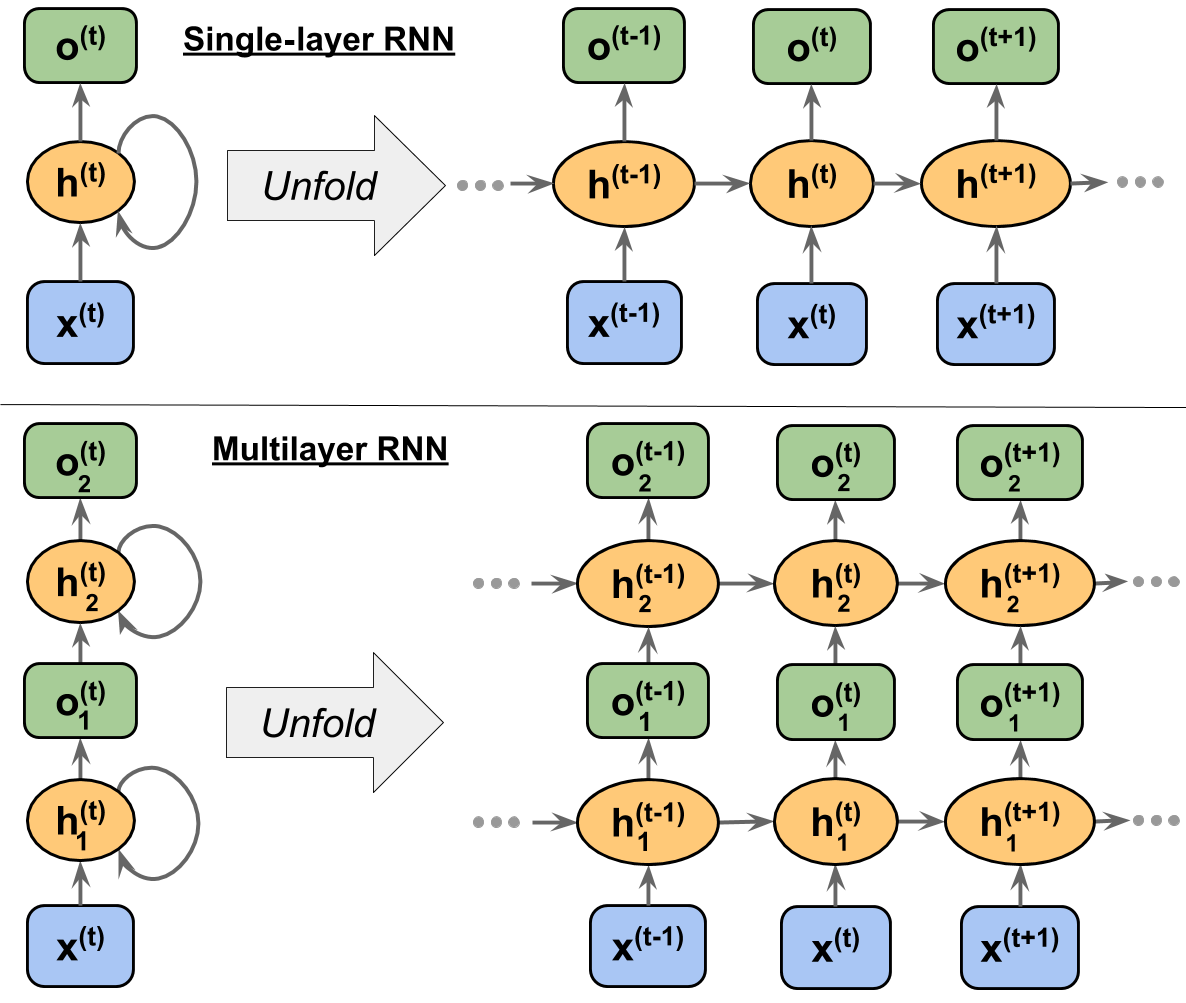

In [9]:
Image(filename='figures/15_04.png', width=500)

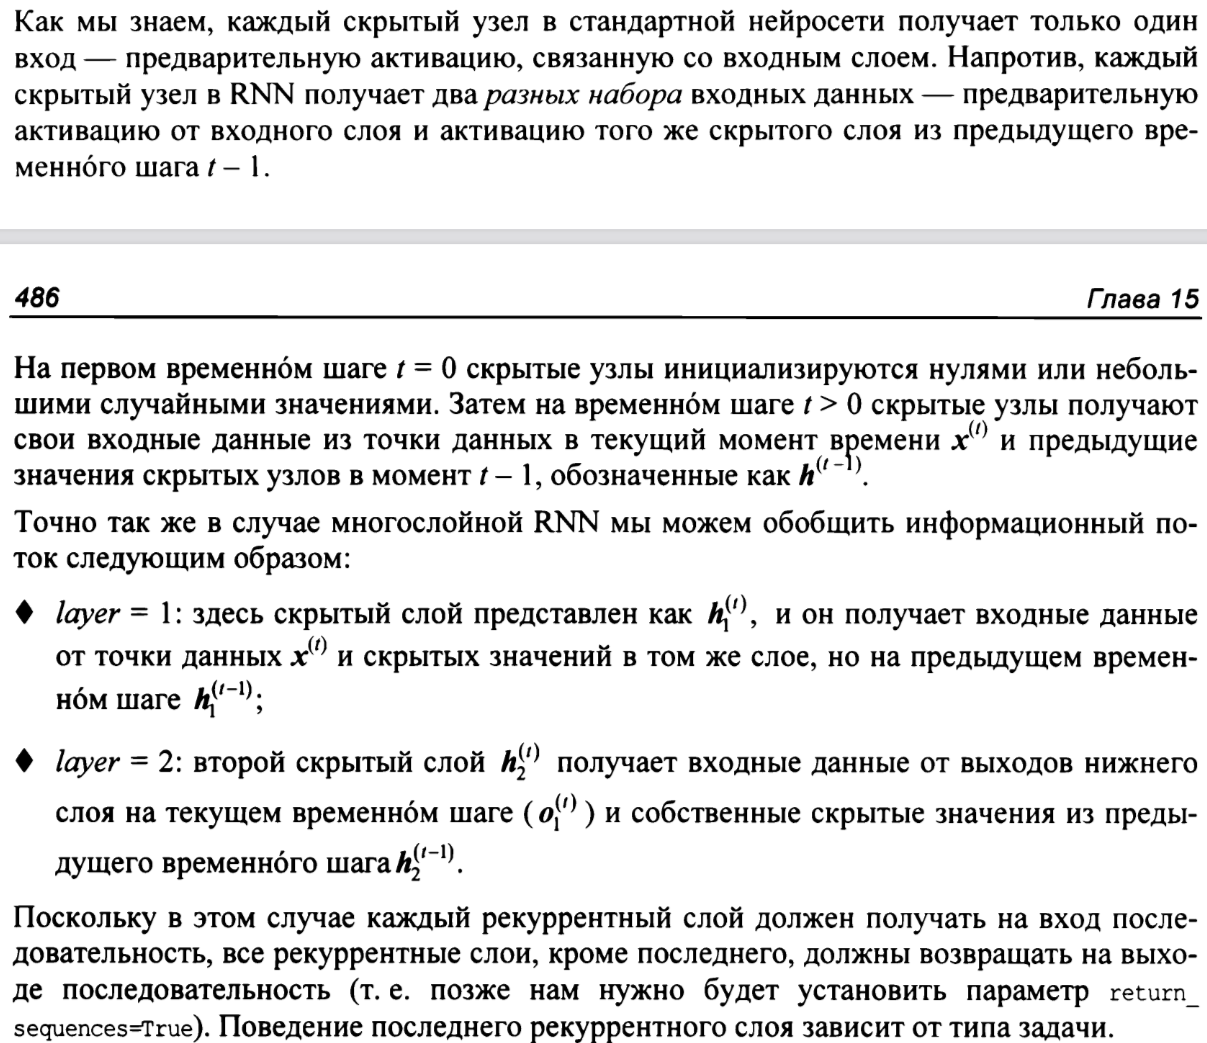

In [11]:
Image(filename='figures/текст5.png', width=700)

### 15.2.2. Вычисление активаций в RNN 

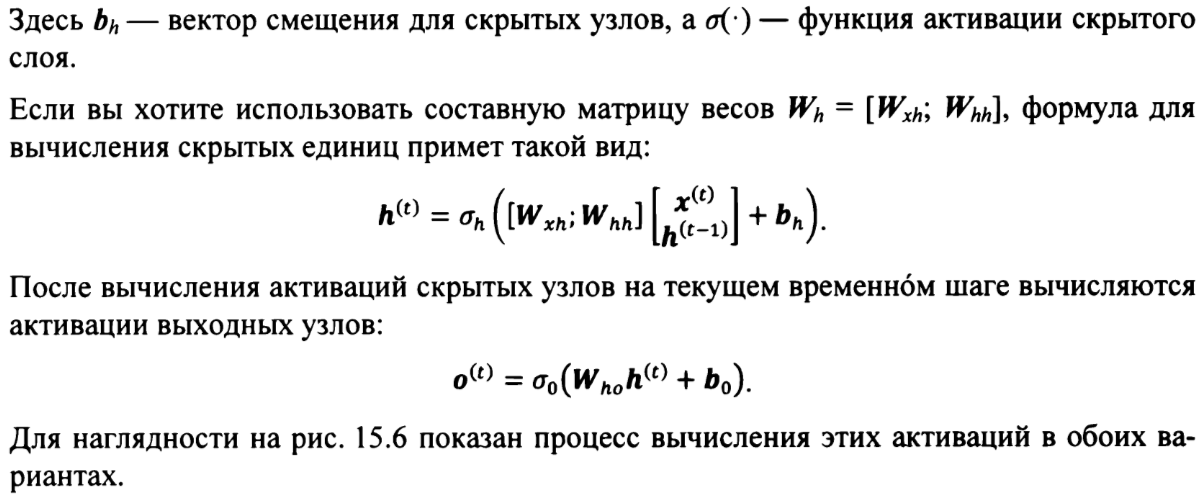

In [ ]:
Image(filename='figures/текст6.png', width=700)

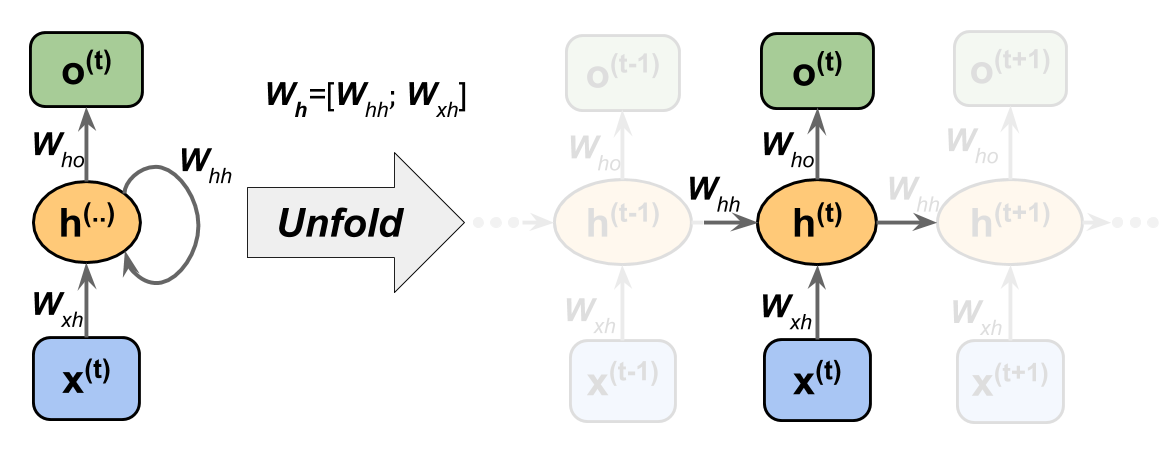

In [13]:
Image(filename='figures/15_05.png', width=500)

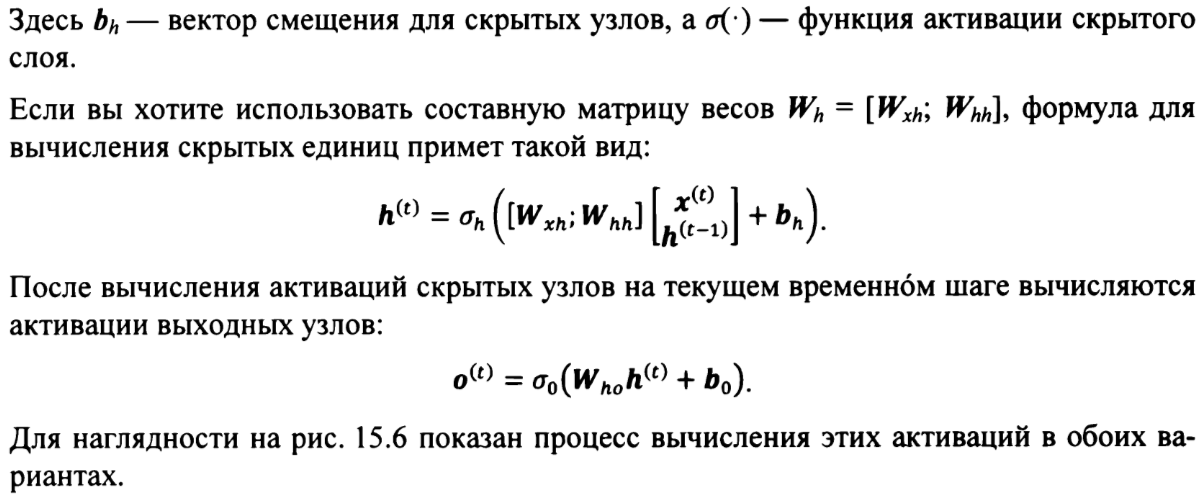

In [15]:
Image(filename='figures/текст7.png', width=700)

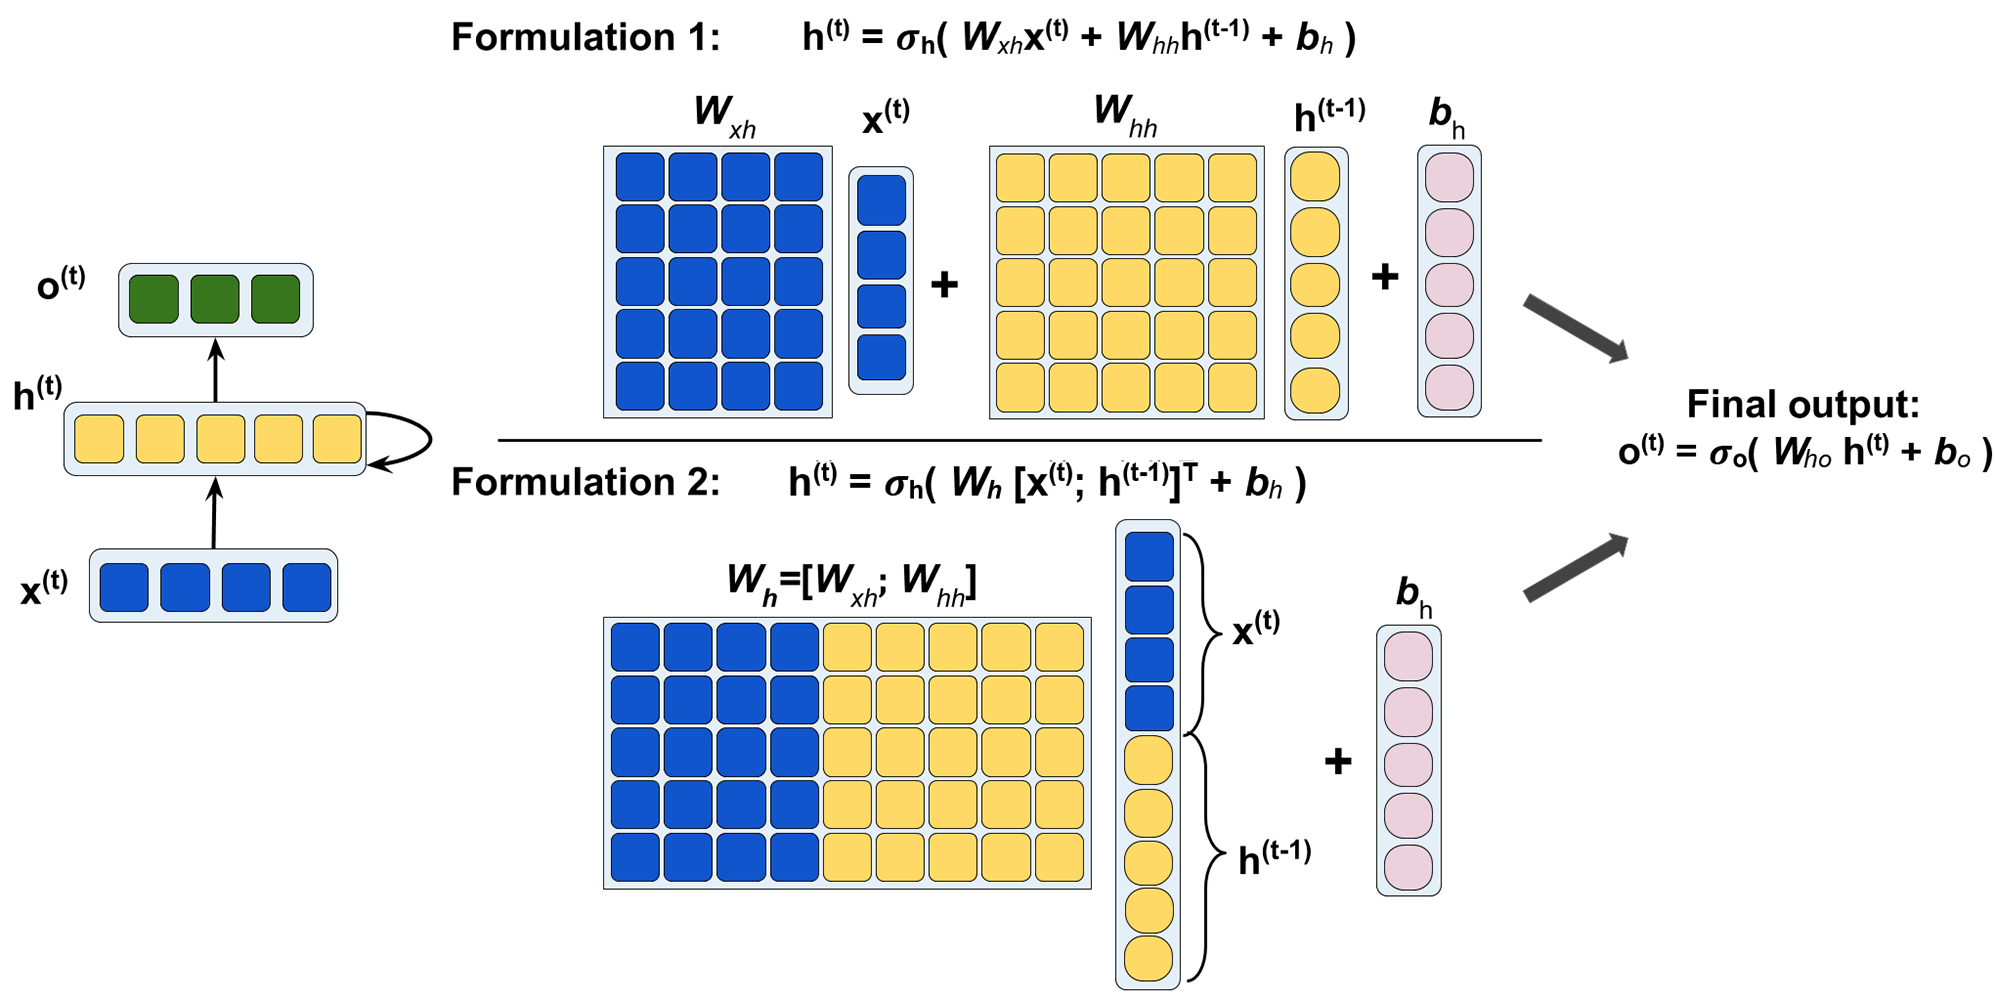

In [16]:
Image(filename='figures/15_06.png', width=700)

### 15.2.3. Скрытая и выходная рекуррентность

До сих пор вы видели рекуррентные сети, в которых рекуррентная петля охватывает скрытый слой. На рис. 15.7  это показано как рекуррентная связь «скрытый к скрытому» 
(hidde-to-hidden recurrence). Однако  надо  сказать,  что  существует  альтернативная модель, в которой рекуррентное соединение исходит из выходного слоя. В этом случае, 
активация сети из выходного слоя на предыдущем временном шаге может быть добавлена одним из двух способов: 
♦  к скрытому слою на текущем временном шаге h1 - показана на рис. 15.7  как рекур­рентная связь «выход к скрытому» (output-to-hidden recurrence); 
♦  к выходному слою на текущем временном шаге 01  - показана на рис. 15.7 как рекуррентная связь «выход к выходу» (output-to-output recurrence). 

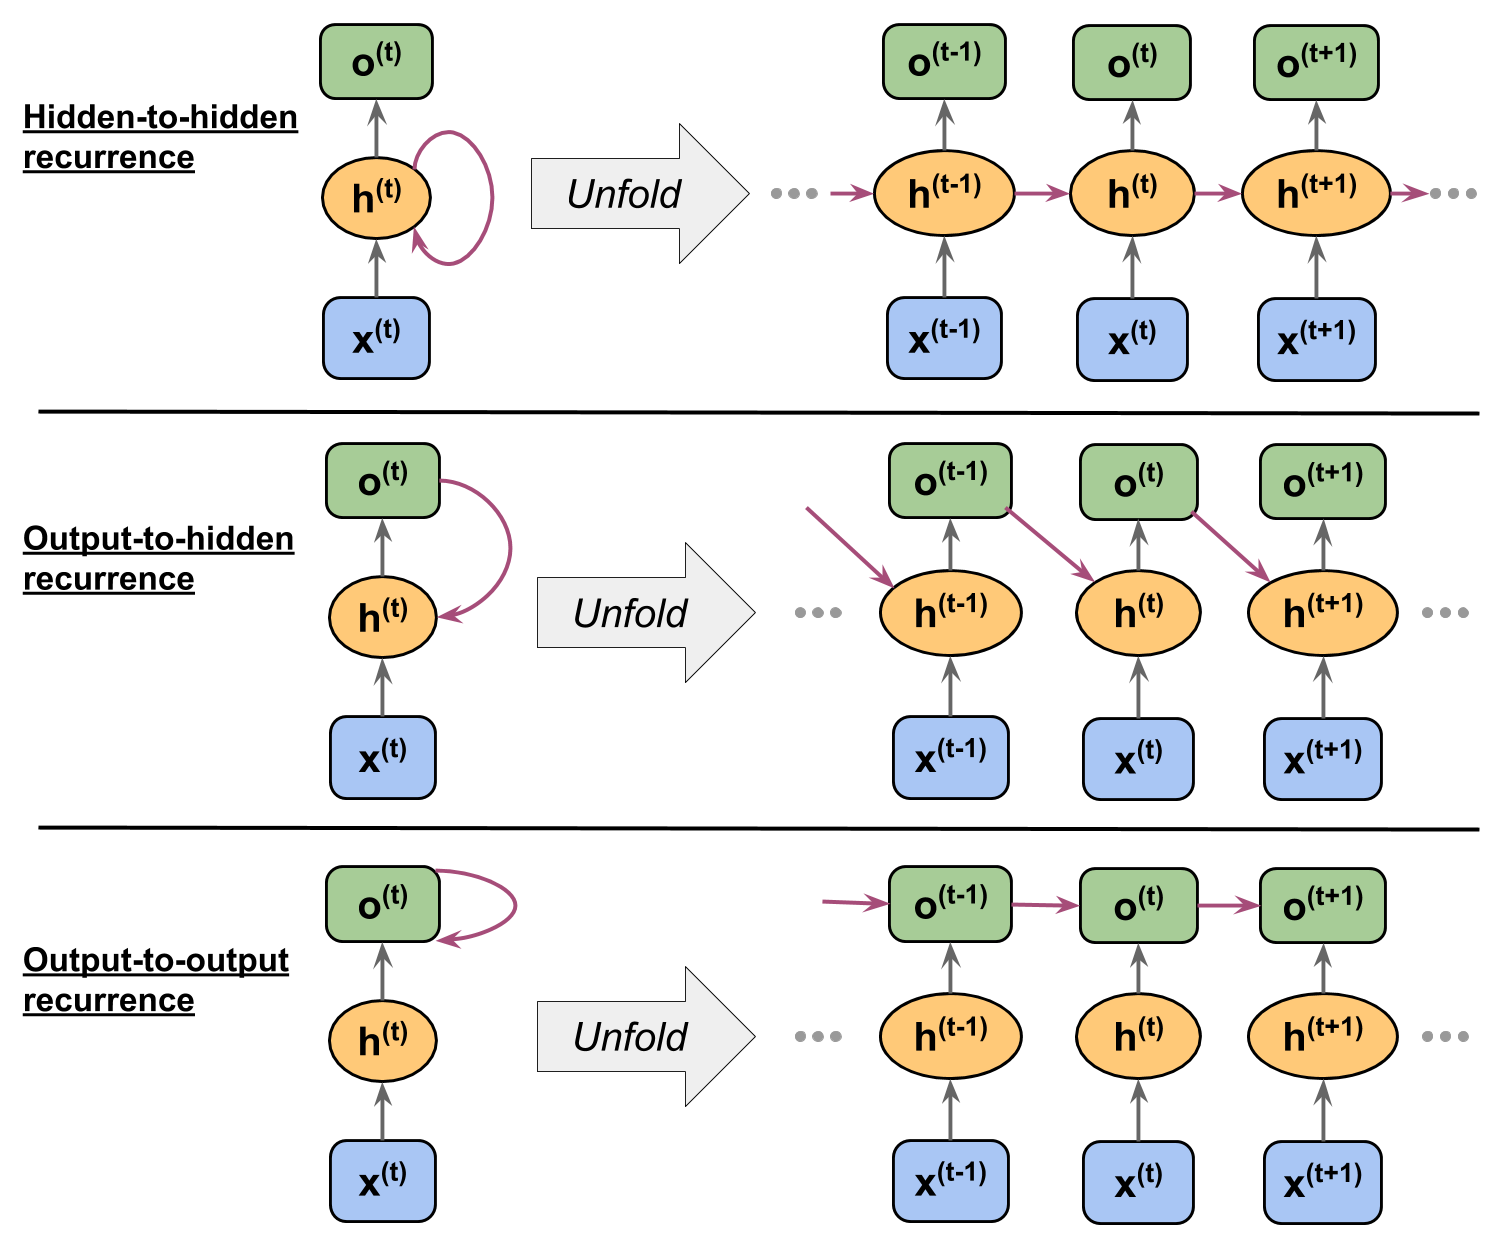

In [17]:
Image(filename='figures/15_07.png', width=500)

Чтобы продемонстрировать, как рекуррентность работает на практике, вручную вычис­лим прямой проход для одного из вариантов рекуррентной модели. С модулем torch.nn 
рекуррентный слой может быть определен через объект RNN, соответствующий рекур­рентной связи от скрытого слоя к скрытому. В следующем коде мы создадим рекур­рентный слой на основе RNN и выполним прямой проход входной последовательности длины 3 для вычисления выходных данных. Мы также вручную вычислим прямой про­ход и сравним результаты с результатами работы RNN. 

Сначала создадим слой и назначим веса и смещения для наших ручных вычислений: 

In [18]:
import torch
import torch.nn as nn

torch.manual_seed(1)
# Создаём экземпляр рекуррентного слоя RNN из PyTorch. Разберём параметры:
# input_size=5 — размерность вектора признаков на каждом временном шаге (то есть на вход в каждый момент подаётся вектор из 5 чисел).
# hidden_size=2 — размерность скрытого состояния (внутренняя память RNN — вектор из 2 чисел).
# num_layers=1 — один слой RNN (не стек из нескольких).
# batch_first=True — входные тензоры будут иметь форму (batch, seq_len, input_size), а не (seq_len, batch, input_size).
# Когда объект создаётся, PyTorch сразу случайно инициализирует все обучаемые параметры (веса и смещения).
rnn_layer = nn.RNN(input_size=5, hidden_size=2, num_layers=1, batch_first=True) 
# Достаём вес, который соединяет вход (input) со скрытым состоянием (hidden) для слоя номер 0. Суффикс _l0 означает "layer 0".
w_xh = rnn_layer.weight_ih_l0
# Достаём вес, который соединяет скрытое состояние предыдущего шага с текущим скрытым состоянием (hidden → hidden), тоже для слоя 0
w_hh = rnn_layer.weight_hh_l0
# Смещение (bias), которое добавляется к вкладу от входа
b_xh = rnn_layer.bias_ih_l0
# Смещение, которое добавляется к вкладу от предыдущего скрытого состояния
b_hh = rnn_layer.bias_hh_l0

print('W_xh shape:', w_xh.shape)
print('W_hh shape:', w_hh.shape)
print('b_xh shape:', b_xh.shape)
print('b_hh shape:', b_hh.shape)

W_xh shape: torch.Size([2, 5])
W_hh shape: torch.Size([2, 2])
b_xh shape: torch.Size([2])
b_hh shape: torch.Size([2])


Теперь выполним прямой проход для rnn_layer, вычислим выходные данные на каждом временн6м шаге и сравним их: 

In [19]:
# создаётся входная последовательность.(тензор формы (3, 5))
x_seq = torch.tensor([[1.0]*5, [2.0]*5, [3.0]*5]).float()

# torch.reshape(x_seq, (1, 3, 5)) — переформировываем тензор из (3, 5) в (1, 3, 5). 
# Три оси: (batch, seq_len, input_size). Мы добавили batch-размерность равную 1. 
# Это нужно, потому что rnn_layer создан с batch_first=True и ожидает именно такую форму.
# rnn_layer(...) — прогоняем данные через RNN.
# На выходе два тензора:
# output — выходы RNN на каждом временном шаге, форма (1, 3, 2) (batch, seq_len, hidden_size).
# hn — финальное скрытое состояние, форма (1, 1, 2) для однослойной RNN (num_layers, batch, hidden_size). 
# В нашем случае hn совпадает с последним выходом output[:, -1], потому что выход RNN — это и есть её скрытое состояние на каждом шаге.
output, hn = rnn_layer(torch.reshape(x_seq, (1, 3, 5)))

## manually computing the output:
out_man = []
for t in range(3):
    xt = torch.reshape(x_seq[t], (1, 5))
    print(f'шaг времени {t} =>')
    print('   Вход            :', xt.numpy())
# ht здесь — это W_xh @ x_t + b_xh   
    ht = torch.matmul(xt, torch.transpose(w_xh, 0, 1)) + b_xh    
    print('   Скрытый         :', ht.detach().numpy())

# Определяем предыдущее скрытое состояние h_{t-1}:
# На первом шаге (t == 0) его ещё нет, поэтому берём нулевой вектор той же формы, что ht, то есть (1, 2). 
# Именно так RNN инициализирует начальное состояние по умолчанию.
# На шагах t > 0 берём то, что посчитали на предыдущей итерации и сохранили в out_man.
    if t>0:
        prev_h = out_man[t-1]
    else:
        prev_h = torch.zeros((ht.shape))

# Считаем полное выражение до активации.
# Итого ot пока равно W_xh @ x_t + b_xh + W_hh @ h_{t-1} + b_hh — ещё без tanh.
    ot = ht + torch.matmul(prev_h, torch.transpose(w_hh, 0, 1)) + b_hh
# Применяем гиперболический тангенс — нелинейность, которая зажимает значения в диапазон (-1, 1). Теперь ot — это настоящее скрытое состояние h_t.
    ot = torch.tanh(ot)
    out_man.append(ot)
    print('   Выход (вручную) :', ot.detach().numpy())
    print('   Выход RNN       :', output[:, t].detach().numpy())
    print()

шaг времени 0 =>
   Вход            : [[1. 1. 1. 1. 1.]]
   Скрытый         : [[-0.4701929  0.5863904]]
   Выход (вручную) : [[-0.3519801   0.52525216]]
   Выход RNN       : [[-0.3519801   0.52525216]]

шaг времени 1 =>
   Вход            : [[2. 2. 2. 2. 2.]]
   Скрытый         : [[-0.88883156  1.2364397 ]]
   Выход (вручную) : [[-0.68424344  0.76074266]]
   Выход RNN       : [[-0.68424344  0.76074266]]

шaг времени 2 =>
   Вход            : [[3. 3. 3. 3. 3.]]
   Скрытый         : [[-1.3074701  1.886489 ]]
   Выход (вручную) : [[-0.8649416   0.90466356]]
   Выход RNN       : [[-0.8649416   0.90466356]]



#### 15.2.4. Проблемы изучения дальних взаимодействий

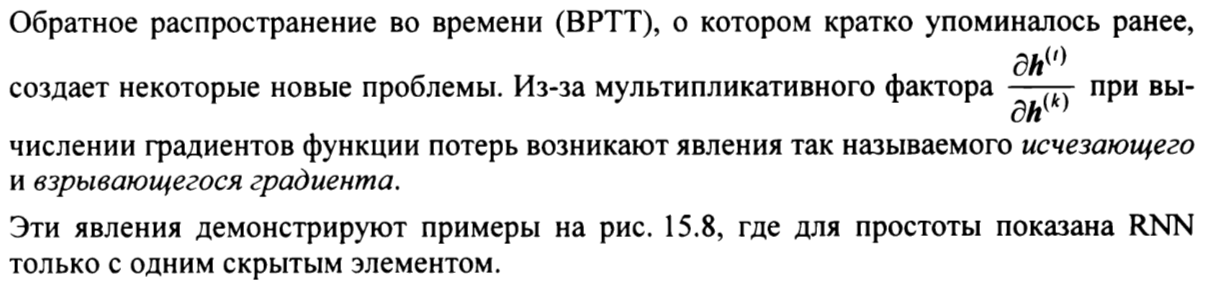

In [21]:
Image(filename='figures/текст8.png', width=500)

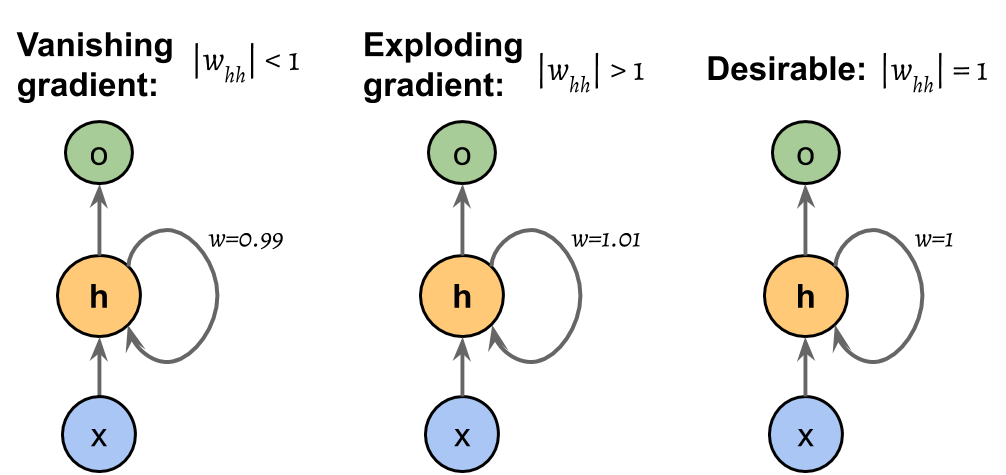

In [22]:
Image(filename='figures/15_08.png', width=500)

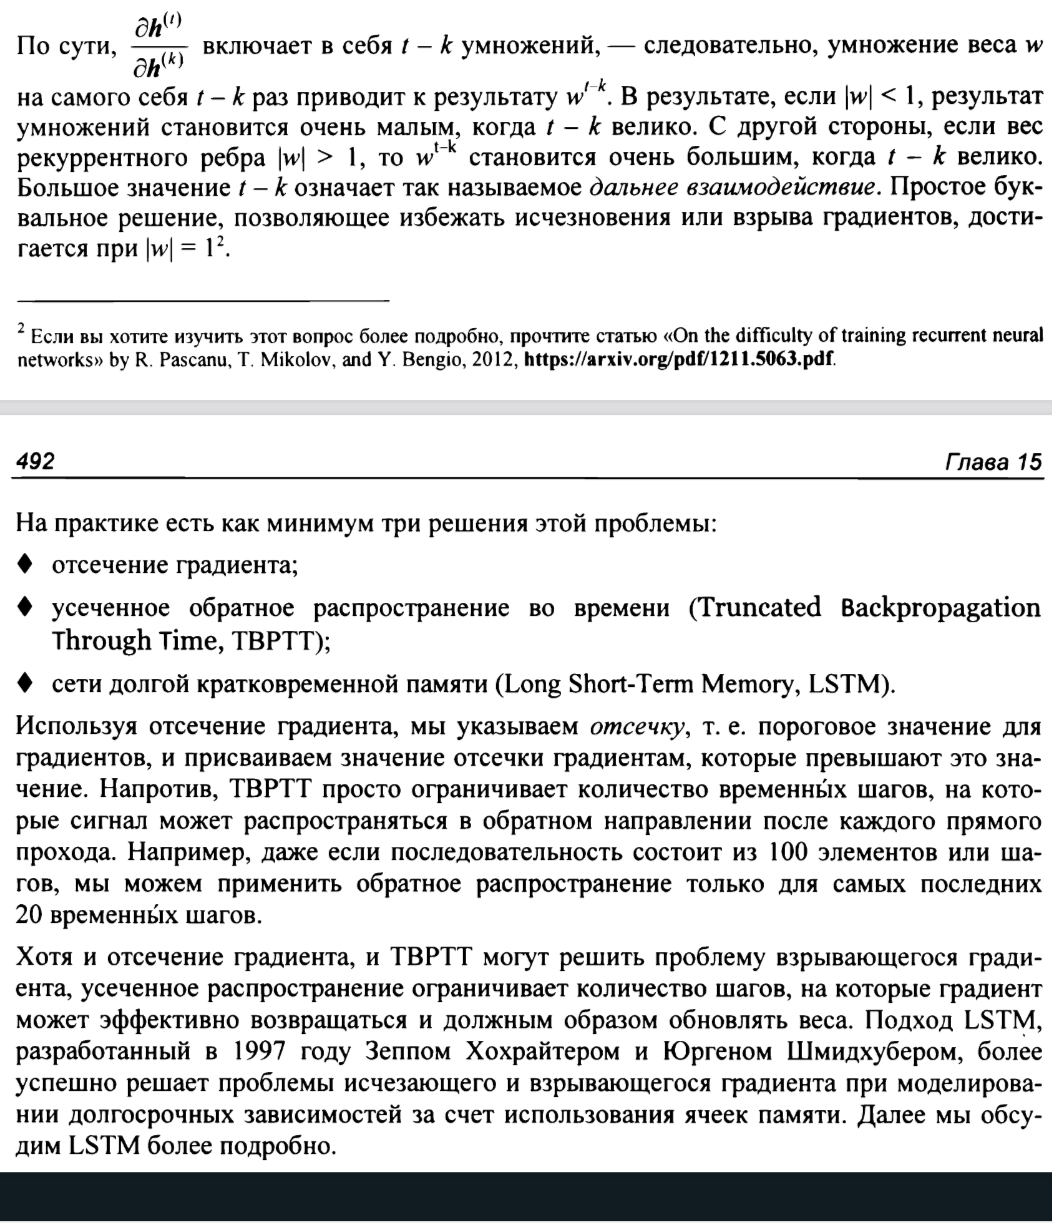

In [23]:
Image(filename='figures/текст9.png', width=700)

#### 15.2.5. Ячейки долгой краткосрочной памяти

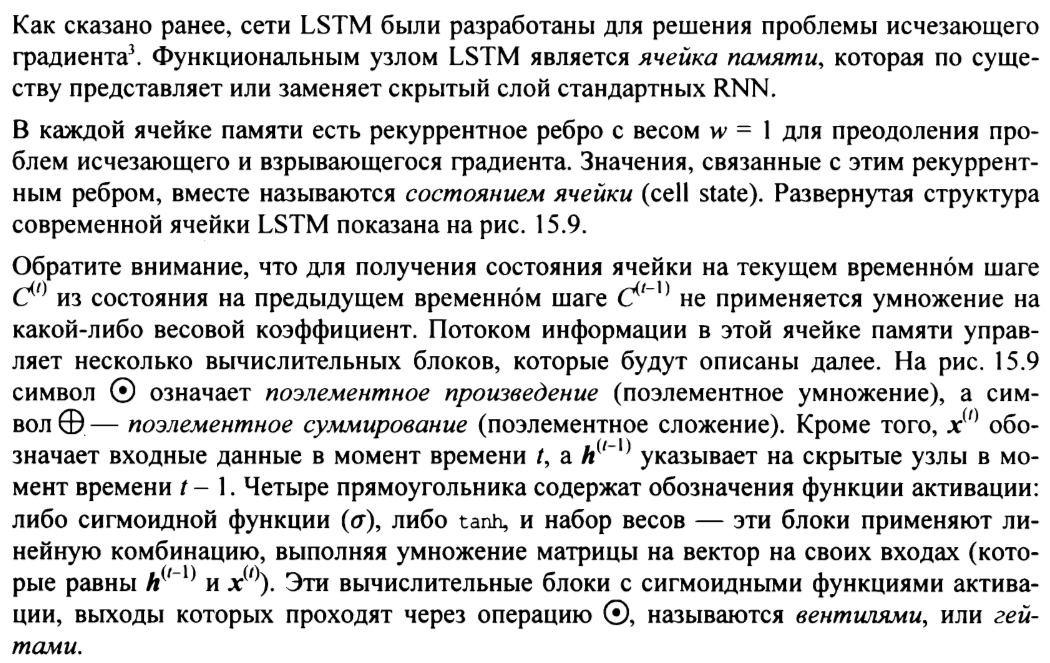

In [24]:
Image(filename='figures/текст10.png', width=700)

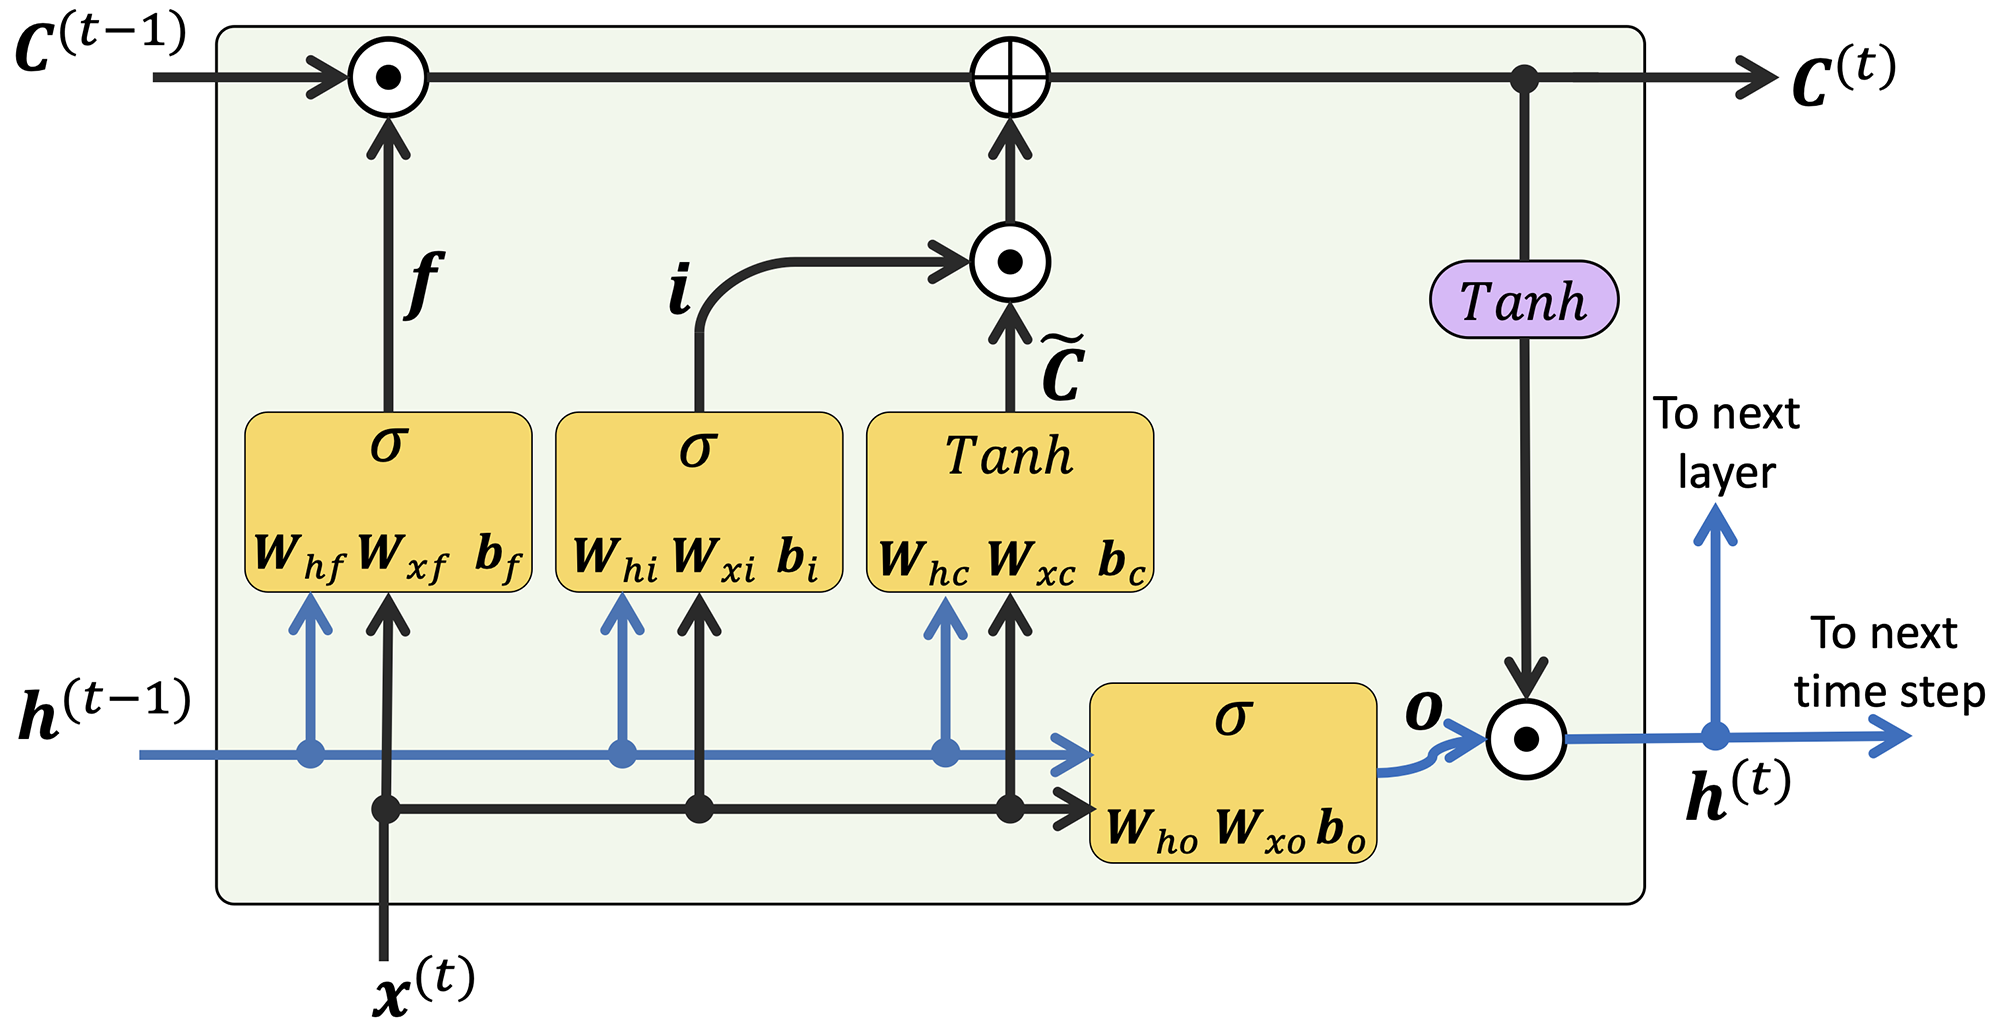

In [10]:
Image(filename='figures/15_09.png', width=500)

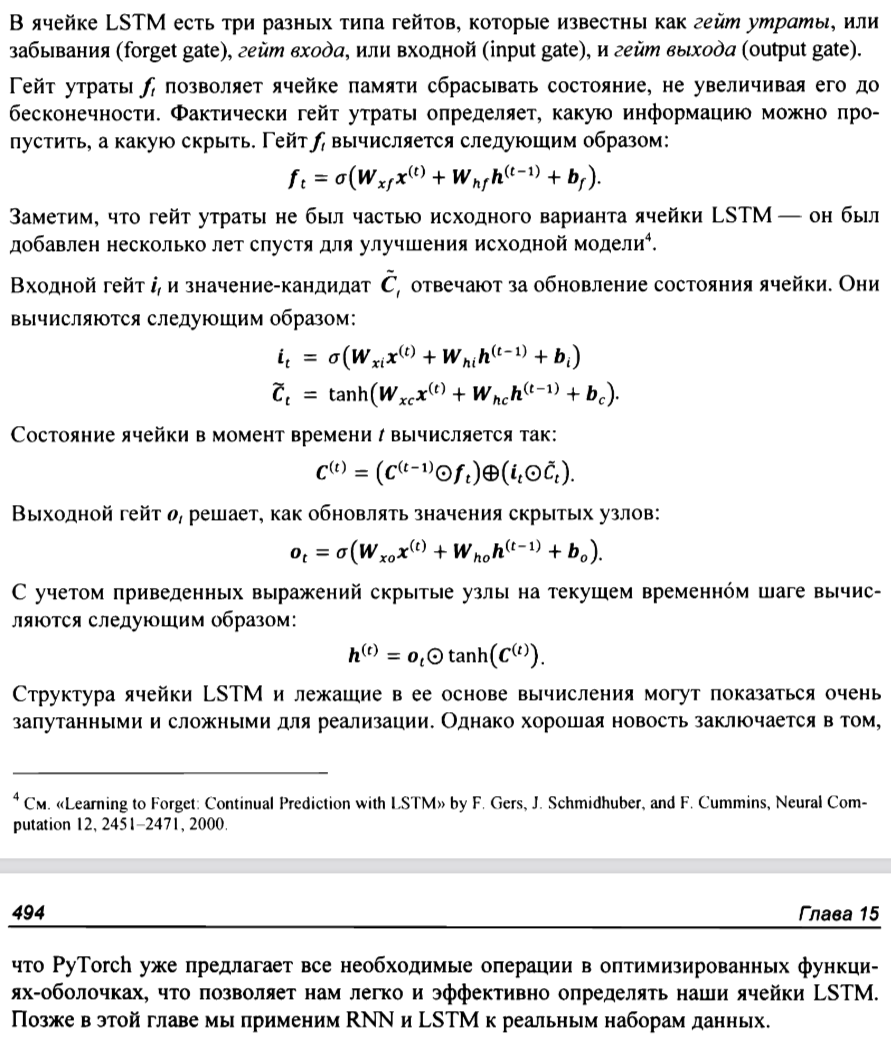

In [25]:
Image(filename='figures/текст11.png', width=700)